In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [ ]:
X, Y, MU = sp.symbols('X Y MU', real=True)

eq1 = X * (2 - X - Y)
eq2 = Y * (MU - Y - (MU**2) * X)

sols = sp.solve((eq1, eq2), (X, Y), dict=True)

print(sols)

[{X: 0, Y: 0}, {X: 0, Y: μ}, {X: 2, Y: 0}, {X: (μ - 2)/((μ - 1)*(μ + 1)), Y: (2*μ**2 - μ)/(μ**2 - 1)}]


In [4]:
def sistema(estado, μ):
    X, Y = estado
    dXdt = X * (2 - X - Y)
    dYdt = Y * (μ - Y - (μ**2) * X)
    return np.array([dXdt, dYdt])

def euler(x0, y0, μ, t0, tf, h):
    num_pasos = int((tf-t0)/h)
    t = np.linspace(t0, tf, num_pasos+1)
    
    X = np.zeros(num_pasos+1)
    X[0] = x0
    Y = np.zeros(num_pasos+1)
    Y[0] = y0 
    
    for i in range(num_pasos):
        estado = np.array([X[i], Y[i]])
        pendiente = sistema(estado, μ)
        
        X[i+1] = X[i] + h * pendiente[0]
        Y[i+1] = Y[i] + h * pendiente[1]
        
    return t, X, Y

def equilibrios(mu):
    X, Y, MU = sp.symbols('X Y MU', real=True)

    eq1 = X * (2 - X - Y)
    eq2 = Y * (MU - Y - (MU**2) * X)

    sols = sp.solve((eq1, eq2), (X, Y), dict=True)

    eqs = []
    for sol in sols:
        x_val = sp.simplify(sol[X].subs(MU, mu))
        y_val = sp.simplify(sol[Y].subs(MU, mu))

        # Nos quedamos solo con los reales
        if x_val.is_real is False or y_val.is_real is False:
            continue

        eqs.append((float(x_val), float(y_val)))

    return eqs

mu = -0.5 -> Equilibrios: [(0.0, 0.0), (0.0, -0.5), (2.0, 0.0), (3.333333333333333, -1.3333333333333333)]


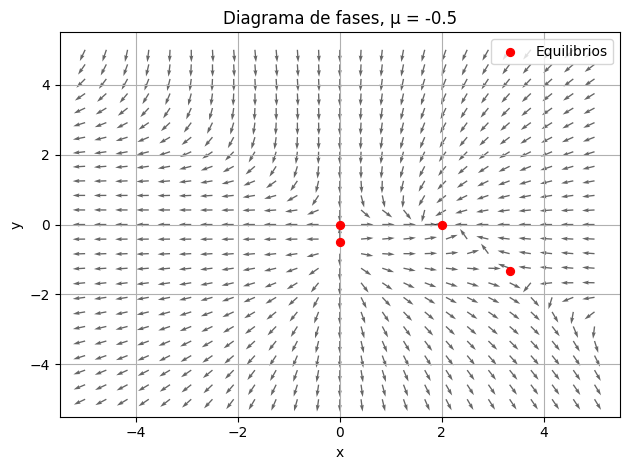

mu = 0 -> Equilibrios: [(0.0, 0.0), (0.0, 0.0), (2.0, 0.0), (2.0, 0.0)]


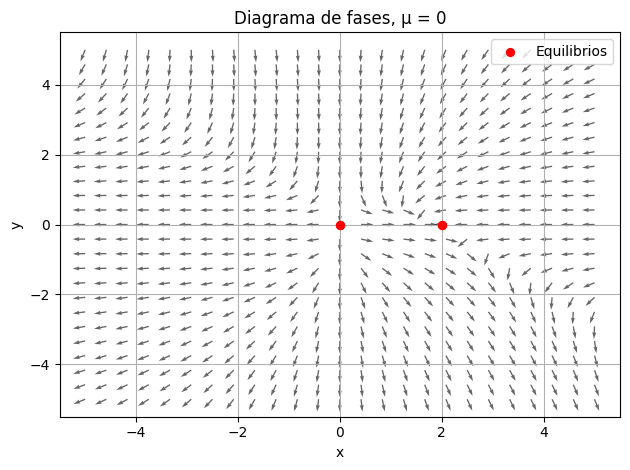

mu = 0.25 -> Equilibrios: [(0.0, 0.0), (0.0, 0.25), (2.0, 0.0), (1.8666666666666667, 0.13333333333333333)]


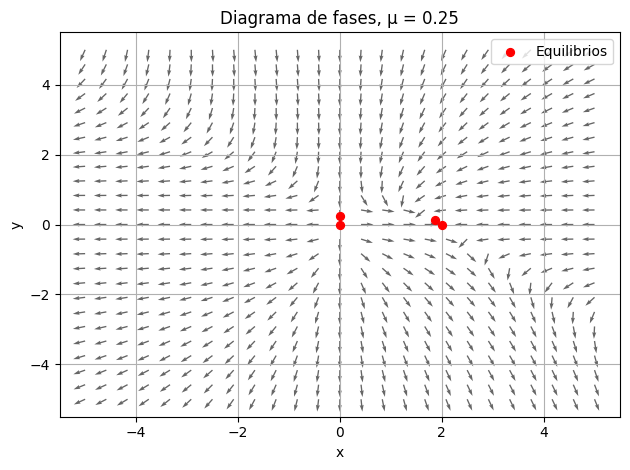

mu = 0.5 -> Equilibrios: [(0.0, 0.0), (0.0, 0.5), (2.0, 0.0), (2.0, 0.0)]


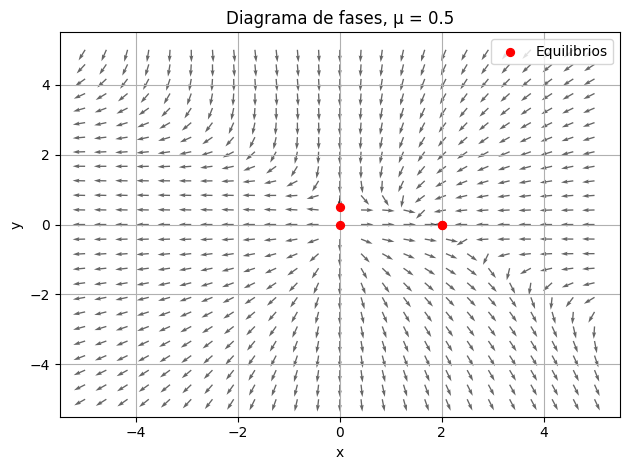

mu = 0.75 -> Equilibrios: [(0.0, 0.0), (0.0, 0.75), (2.0, 0.0), (2.8571428571428568, -0.8571428571428571)]


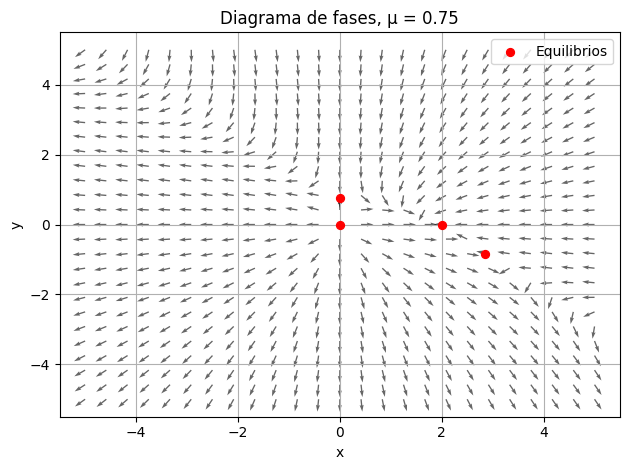

In [10]:
mus = [-1/2, 0, 1/4, 1/2, 3/4]

for μ in mus:
    
    eqs = equilibrios(μ)
    print(f"mu = {μ} -> Equilibrios: {eqs}")
    
    
    # Campo vectorial
    x_vals = np.linspace(-5, 5, 25)
    y_vals = np.linspace(-5, 5, 25)
    X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

    U = X_grid * (2 - X_grid - Y_grid)
    V = Y_grid * (μ - Y_grid - (μ**2) * X_grid)

    norma = np.sqrt(U**2 + V**2)
    norma[norma == 0] = 1

    U_norm = U / norma
    V_norm = V / norma
    
    # Gráfico
    
    plt.quiver(X_grid, Y_grid, U_norm, V_norm, alpha=0.6)
    
    '''    
    # Trayectorias
    for x0, y0 in condiciones_iniciales:
        t, x, y = euler(x0, y0, μ, 0, 15, 0.01)
        plt.plot(x, y)
    '''
    
        
    if len(eqs) > 0:
        eq_x = [p[0] for p in eqs]
        eq_y = [p[1] for p in eqs]
        plt.scatter(eq_x, eq_y, color='red', s=32, label='Equilibrios', zorder=5)
        
    plt.title(f'Diagrama de fases, μ = {μ}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()